# WM-811K 웨이퍼맵 Classfication

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt

## 1. EDA

In [2]:
with open("WM811K.pkl", "rb") as f:
    df = pd.read_pickle(f)

# 데이터 라벨 종류
print(df.head())

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  


In [3]:
def extract_failure(x):
    try:
        return x[0][0]
    except:
        return 'none'

df['failureType_clean'] = df['failureType'].apply(extract_failure)

In [4]:
df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)

In [5]:
# Training 데이터만 선택 (빈 리스트/ndarray 처리 포함)
def get_label_first(x):
    if isinstance(x, (list, np.ndarray)):
        if len(x) > 0:
            return x[0]
        else:
            return None  # 빈 리스트는 None 처리
    else:
        return x

train_df = df[df['trainTestLabel'].apply(get_label_first) == 'Training']

# 각 failureTypeStr별 개수
train_counts = train_df['failureType'].value_counts()

print("=== Training 데이터 클래스별 개수 ===")
print(train_counts)

=== Training 데이터 클래스별 개수 ===
failureType
[[none]]         36730
[[Edge-Ring]]     8554
[[Center]]        3462
[[Edge-Loc]]      2417
[[Loc]]           1620
[[Random]]         609
[[Scratch]]        500
[[Donut]]          409
[[Near-full]]       54
Name: count, dtype: int64


In [6]:
def extract_label(x):
    try:
        return x[0][0]
    except:
        return 'unknown'


# 라벨 종류
label_type = df['trainTestLabel'].apply(extract_label).unique()
print("kind: ", end='')
print(*label_type, sep=', ')

# ndarray 개수 (이건 컬럼 잘못 잡았었음 → 수정)
label_zerocount = df['trainTestLabel'].apply(lambda x: isinstance(x, np.ndarray)).sum()
print(f"trainTestLabel 컬럼의 ndarray cell 개수: {label_zerocount}")

kind: Training, unknown, Test
trainTestLabel 컬럼의 ndarray cell 개수: 811457


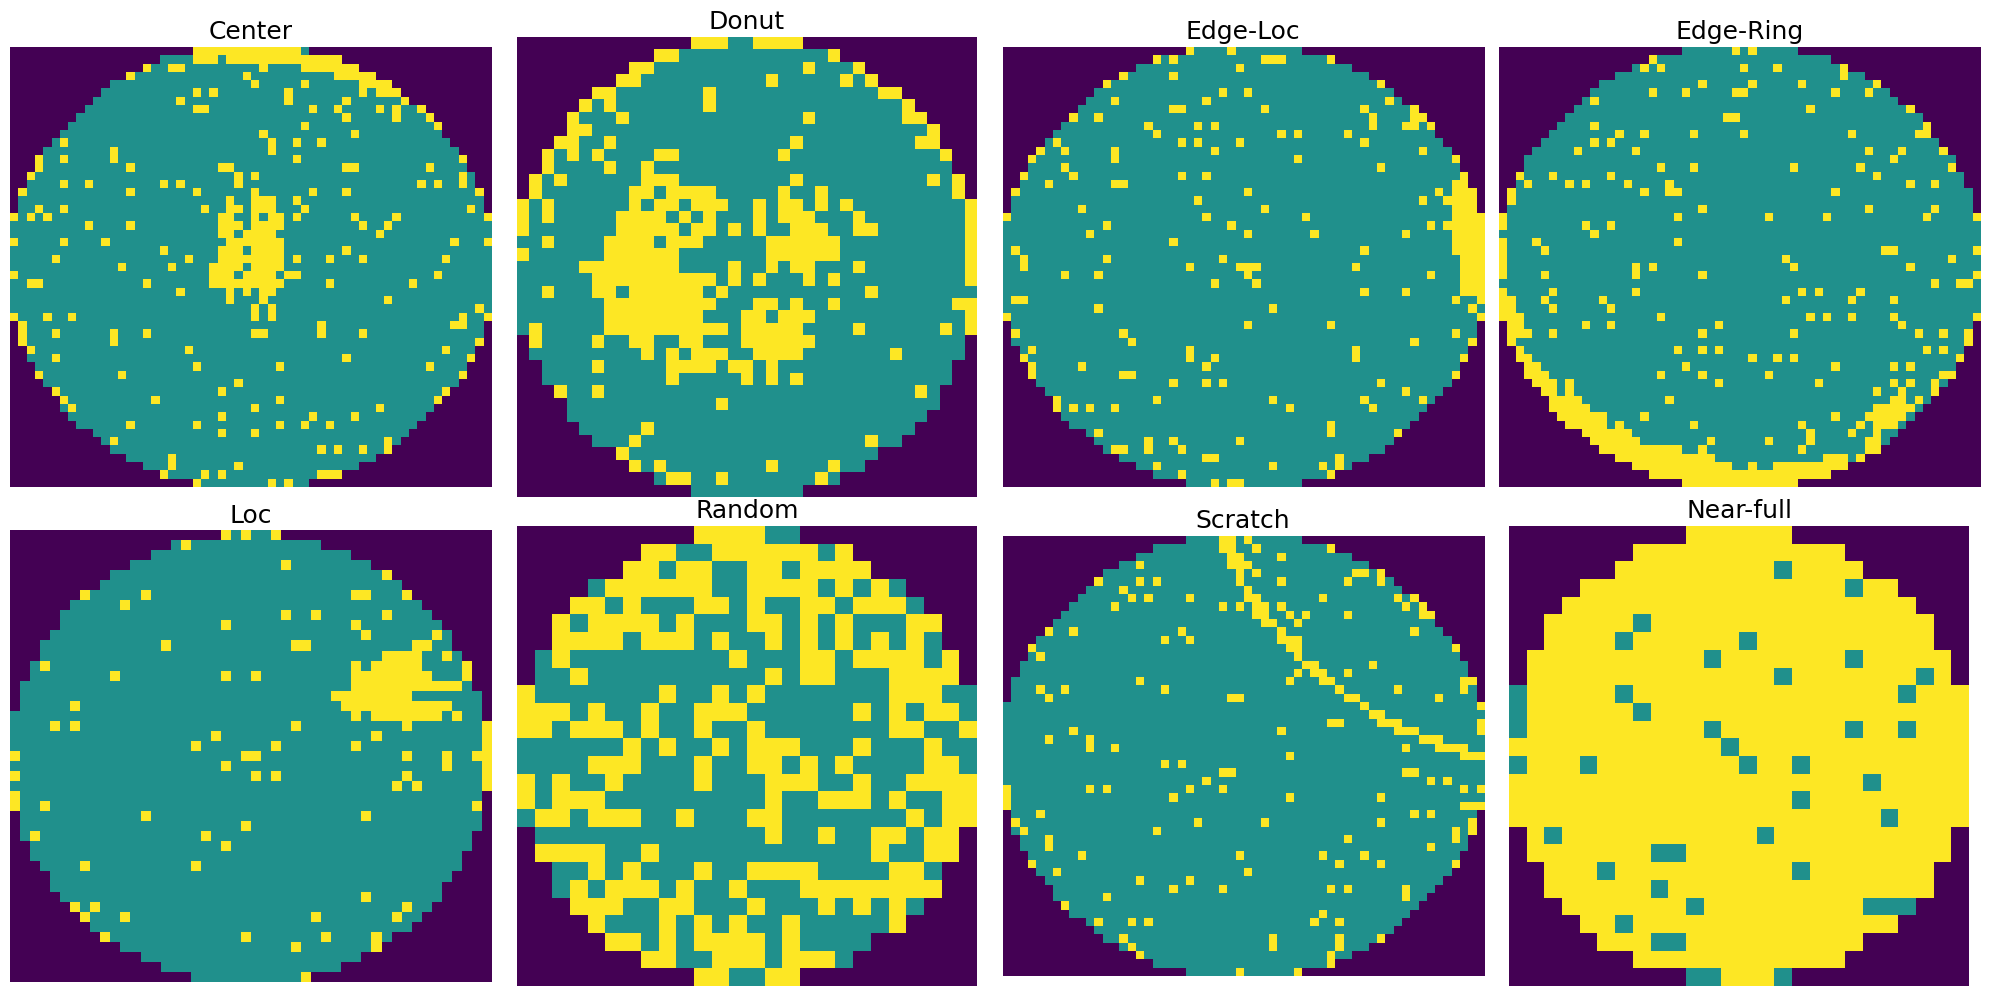

In [7]:
# ✅ failureType 완전 정리 (이중 ndarray → string)
def extract_failure(x):
    try:
        return x[0][0]
    except:
        return 'none'

df['failureTypeStr'] = df['failureType'].apply(extract_failure)


# ✅ 불량 타입
failure_types = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']


# ✅ 샘플 인덱스 선택
x = []
for ft in failure_types:
    subset = df[df['failureTypeStr'] == ft]
    if len(subset) > 0:
        x.append(subset.index[0])


# ✅ 시각화
fig, ax = plt.subplots(2, 4, figsize=(20,10))
ax = ax.ravel()

for i, idx in enumerate(x):
    img = df.loc[idx, 'waferMap']
    title = df.loc[idx, 'failureTypeStr']
    
    # 🔥 waferMap이 0/1/2 값이라면 컬러맵 지정 추천
    ax[i].imshow(img)
    ax[i].set_title(title, fontsize=18)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

---
### 두 경우에 대해서 ndarray(0)인 데이터의 개수가 638507로 일치하므로 이는 미지정데이터

---

## 2. 데이터 전처리

In [8]:
def extract_label(x):
    try:
        return x[0][0]
    except:
        return 'unknown'

# clean 컬럼 생성
df['trainTestLabel_clean'] = df['trainTestLabel'].apply(extract_label)

# index 분리
trainidx = df[df['trainTestLabel_clean'] == 'Training'].index
testidx  = df[df['trainTestLabel_clean'] == 'Test'].index

In [9]:
# wafermap과 failureType train데이터 선택
X_train = df.loc[trainidx, 'waferMap']
y_train = df.loc[trainidx, 'failureType']

# wafermap과 failureType test데이터 선택
X_test = df.loc[testidx, 'waferMap']
y_test = df.loc[testidx, 'failureType']

In [10]:
# waferMap 확인
print("X_train type example:", type(X_train.iloc[0]))
print("X_test type example:", type(X_test.iloc[0]))

# failureType 확인
print("y_train type example:", type(y_train.iloc[0]))
print("y_test type example:", type(y_test.iloc[0]))

X_train type example: <class 'numpy.ndarray'>
X_test type example: <class 'numpy.ndarray'>
y_train type example: <class 'numpy.ndarray'>
y_test type example: <class 'numpy.ndarray'>


In [11]:
shapes = X_train.apply(lambda x: x.shape if isinstance(x, np.ndarray) else None)
print(shapes.value_counts())  # 어떤 shape가 있는지 확인

waferMap
(25, 27)      15684
(27, 25)       9235
(26, 26)       6369
(38, 36)       1877
(33, 37)       1804
              ...  
(122, 102)        1
(50, 68)          1
(26, 30)          1
(41, 30)          1
(72, 50)          1
Name: count, Length: 335, dtype: int64


In [12]:
# 모든 waferMap shape 확인
shapes = X_train.apply(lambda x: x.shape if isinstance(x, np.ndarray) else (0,0))

# 최대 height와 width 확인
max_h = max([s[0] for s in shapes])
max_w = max([s[1] for s in shapes])

print("Maximum waferMap size:", max_h, "x", max_w)

Maximum waferMap size: 212 x 204


In [13]:
# 필터링: 64x64 넘는 wafer를 고려하면 20GB가 넘어가 매우 무거워짐 -> 제외 따라서 제외
max_dim = 64

# train에서 64x64 넘는 wafer 개수
num_train_large = sum((X_train.apply(lambda x: x.shape[0] > max_dim or x.shape[1] > max_dim)))
print(f"Train wafer >64x64: {num_train_large} / {len(X_train)}")

# test에서 64x64 넘는 wafer 개수
num_test_large = sum((X_test.apply(lambda x: x.shape[0] > max_dim or x.shape[1] > max_dim)))
print(f"Test wafer >64x64: {num_test_large} / {len(X_test)}")

Train wafer >64x64: 3156 / 54355
Test wafer >64x64: 325 / 118595


In [14]:
# 데이터 손실률이 Train에서 5.8%, Test에서 0.27%이므로 삭제
mask_train = X_train.apply(lambda x: x.shape[0] <= max_dim and x.shape[1] <= max_dim)
mask_test  = X_test.apply(lambda x: x.shape[0] <= max_dim and x.shape[1] <= max_dim)

X_train_filtered = X_train[mask_train]
y_train_filtered = y_train[mask_train]

X_test_filtered  = X_test[mask_test]
y_test_filtered  = y_test[mask_test]

In [15]:
def extract_failure(x):
    try:
        return x[0][0]
    except:
        return 'none'

y_train_clean = y_train_filtered.apply(extract_failure)
y_test_clean  = y_test_filtered.apply(extract_failure)

In [30]:
# -----------------------------
# 0. y_train_clean / y_test_clean 생성
# -----------------------------
def extract_failure(x):
    try:
        return x[0][0]
    except:
        return 'none'

y_train_clean = y_train_filtered.apply(extract_failure).astype(str)
y_test_clean  = y_test_filtered.apply(extract_failure).astype(str)

# -----------------------------
# 1. 데이터 증강 함수
# -----------------------------
def shift_image(img, shift_x, shift_y):
    h, w = img.shape
    new_img = np.zeros_like(img)

    x1 = max(0, shift_x)
    x2 = min(h, h + shift_x)
    y1 = max(0, shift_y)
    y2 = min(w, w + shift_y)

    new_img[x1:x2, y1:y2] = img[x1-shift_x:x2-shift_x, y1-shift_y:y2-shift_y]
    return new_img

def augment_wafer(img):
    img_aug = np.array(img)

    if img_aug.ndim != 2 or img_aug.size == 0:
        return img_aug

    # flip
    if np.random.rand() < 0.5:
        img_aug = np.flipud(img_aug)
    if np.random.rand() < 0.5:
        img_aug = np.fliplr(img_aug)

    # rotation
    k = np.random.choice([0, 1, 2, 3])
    img_aug = np.rot90(img_aug, k)

    # shift
    shift_x = np.random.randint(-3, 4)
    shift_y = np.random.randint(-3, 4)
    img_aug = shift_image(img_aug, shift_x, shift_y)

    # noise
    if np.random.rand() < 0.3:
        noise = np.random.normal(0, 0.02, img_aug.shape)
        img_aug = img_aug + noise
'''
    if np.random.rand() < 0.3:
        scale = np.random.uniform(0.8, 1.2)
        img_aug = img_aug * scale
'''
    return img_aug

# -----------------------------
# 2. 중앙정렬 패딩 함수
# -----------------------------
def pad_center(img, target_shape=(64,64)):
    h, w = img.shape
    h_pad_total = target_shape[0] - h
    w_pad_total = target_shape[1] - w
    h_pad_top = h_pad_total // 2
    h_pad_bottom = h_pad_total - h_pad_top
    w_pad_left = w_pad_total // 2
    w_pad_right = w_pad_total - w_pad_left
    return np.pad(img, ((h_pad_top, h_pad_bottom), (w_pad_left, w_pad_right)), mode='constant')

# -----------------------------
# 3. 증강 배율 설정
# -----------------------------
augmentation_dict = {
    'Loc': 2,
    'Random': 5,
    'Scratch': 6,
    'Donut': 6,
    'Near-full': 30
}

# -----------------------------
# 4. 증강 적용
# -----------------------------
X_train_aug, y_train_aug = [], []

for ft, mult in augmentation_dict.items():
    subset_idx = [i for i, lbl in enumerate(y_train_clean) if lbl == ft]
    for idx in subset_idx:
        img = X_train_filtered.iloc[idx]
        label = y_train_clean.iloc[idx]
        X_train_aug.append(img)
        y_train_aug.append(label)
        for _ in range(mult-1):
            X_train_aug.append(augment_wafer(img))
            y_train_aug.append(label)

# 증강 제외 클래스 그대로 추가
majority_idx = [i for i, lbl in enumerate(y_train_clean) if lbl not in augmentation_dict]
for idx in majority_idx:
    X_train_aug.append(X_train_filtered.iloc[idx])
    y_train_aug.append(y_train_clean.iloc[idx])

# -----------------------------
# 5. 중앙정렬 패딩 적용
# -----------------------------
target_shape = (64,64)
X_train_padded = [pad_center(np.array(img), target_shape) for img in X_train_aug]
X_test_padded  = [pad_center(np.array(img), target_shape) for img in X_test_filtered]

# -----------------------------
# 6. Stack + 채널 차원 추가
# -----------------------------
X_train_stack = np.expand_dims(np.stack(X_train_padded), axis=1)
X_test_stack  = np.expand_dims(np.stack(X_test_padded), axis=1)

# -----------------------------
# 7. Tensor 변환 및 LabelEncoder
# -----------------------------
X_train_tensor = torch.tensor(X_train_stack, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_stack, dtype=torch.float32)

# LabelEncoder fit/transform
le = LabelEncoder()
y_train_enc = le.fit_transform(pd.Series(y_train_aug).astype(str))
y_test_enc  = le.transform(y_test_clean.astype(str))

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_enc, dtype=torch.long)

# -----------------------------
# 8. 확인
# -----------------------------
print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([59981, 1, 64, 64]) torch.float32
X_test_tensor: torch.Size([118270, 1, 64, 64]) torch.float32
y_train_tensor: torch.Size([59981]) torch.int64
y_test_tensor: torch.Size([118270]) torch.int64


In [17]:
# GPU와 잘 연결됐는지 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 3. CNN 딥러닝 실행

In [25]:
num_classes = len(le.classes_)

# -----------------------------
# 데이터셋 준비 (기존 X_train_tensor, y_train_tensor 가정)
# -----------------------------
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

'\n# -----------------------------\n# ResNet18 모델 정의\n# -----------------------------\nnum_classes = len(le.classes_)  # failureType 종류 수\n\nmodel = resnet18(weights=None)              # 사전학습 없이 사용\nmodel.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2, bias=False)  # 1채널 입력용\nmodel.fc = nn.Linear(model.fc.in_features, num_classes)  # 클래스 수 맞춤\nmodel = model.to(device)\n\n# -----------------------------\n# Loss, Optimizer\n# -----------------------------\ncriterion = nn.CrossEntropyLoss()\noptimizer = optim.Adam(model.parameters(), lr=0.001)\n\n\n# -----------------------------\n# 학습 루프\n# -----------------------------\nnum_epochs = 10  # 필요에 따라 늘릴 수 있음\n\nfor epoch in range(num_epochs):\n    model.train()\n    running_loss = 0.0\n    for X_batch, y_batch in train_loader:\n        X_batch, y_batch = X_batch.to(device), y_batch.to(device)\n\n        optimizer.zero_grad()\n        outputs = model(X_batch)\n        loss = criterion(outputs, y_batch)\n        loss.backward()\n 

In [31]:
import random
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# ✅ 시드 설정 함수
# -----------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# -----------------------------
# ✅ class weight 계산
# -----------------------------
y_train_np = y_train_tensor.cpu().numpy()

classes = np.arange(num_classes)  # 🔥 중요 (LabelEncoder 순서 맞춤)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_np
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)


# -----------------------------
# 설정
# -----------------------------
num_runs = 3
num_epochs = 20

all_acc = []
all_f1 = []

# -----------------------------
# 반복 실험
# -----------------------------
for run in range(num_runs):
    print(f"\n===== Run {run+1}/{num_runs} =====")

    # ✅ run마다 다른 seed
    set_seed(42 + run)

    # -----------------------------
    # 모델 생성
    # -----------------------------
    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=13, stride=2, padding=6, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # -----------------------------
    # 학습
    # -----------------------------
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # print(f"[Run {run+1}] Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}")

    # -----------------------------
    # 평가
    # -----------------------------
    model.eval()
    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1)

            predicted = []
            for p in probs:
                if torch.max(p) < 0.6:   # threshold
                    predicted.append(8)  # ⚠️ normal class index 확인 필요
                else:
                    predicted.append(torch.argmax(p).item())
            
            predicted = torch.tensor(predicted, dtype=torch.long).to(device)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = 100 * correct / total
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    all_acc.append(acc)
    all_f1.append(f1)

    print(f"[Run {run+1}] Accuracy: {acc:.2f}% | F1(macro): {f1:.4f}")

# -----------------------------
# 최종 결과
# -----------------------------
print("\n===== Final Result =====")
print(f"Accuracy Mean: {np.mean(all_acc):.2f}%")
print(f"Accuracy Std:  {np.std(all_acc):.2f}%")

print(f"F1 Mean: {np.mean(all_f1):.4f}")
print(f"F1 Std:  {np.std(all_f1):.4f}")

print("All Accuracy:", all_acc)
print("All F1:", all_f1)


# -----------------------------
# ✅ Confusion Matrix (마지막 run 기준)
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)


===== Run 1/3 =====
[Run 1] Accuracy: 87.69% | F1(macro): 0.5383

===== Run 2/3 =====


KeyboardInterrupt: 

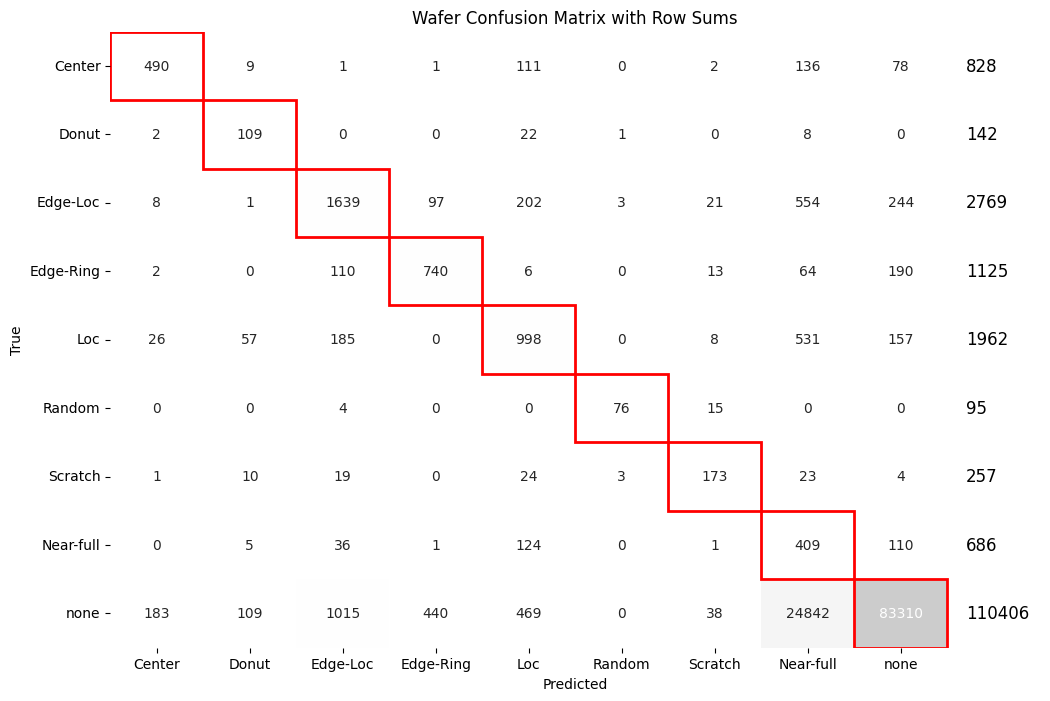

In [56]:
import seaborn as sns

# cm : confusion matrix
# labels : 클래스 이름 리스트
labels = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full','none']

fig, ax = plt.subplots(figsize=(12,8))

# 1️⃣ 전체 배경 연하게
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greys',   # 연한 배경
    cbar=False,
    xticklabels=labels,
    yticklabels=labels,
    alpha=0.2,
    ax=ax
)

# 2️⃣ 대각선만 빨간 테두리
n = len(labels)
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='red', lw=2))

# 3️⃣ 행 합계 표시
row_sum = cm.sum(axis=1)
for i in range(n):
    ax.text(n + 0.2, i + 0.5, row_sum[i], va='center', ha='left', fontsize=12)

# 4️⃣ 축 설정
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_yticklabels(labels, rotation=0)  # y축 가로
ax.set_xticklabels(labels, rotation=0) # x축 세로
ax.set_xlim(0, n + 1)
ax.set_ylim(n, 0)
plt.title("Wafer Confusion Matrix with Row Sums")
plt.show()